# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 26     |  |
| :-------------|:-------------|
| Frank de Kogel| 6582737 |
| Xin Qi Huang  | 6345735 |

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

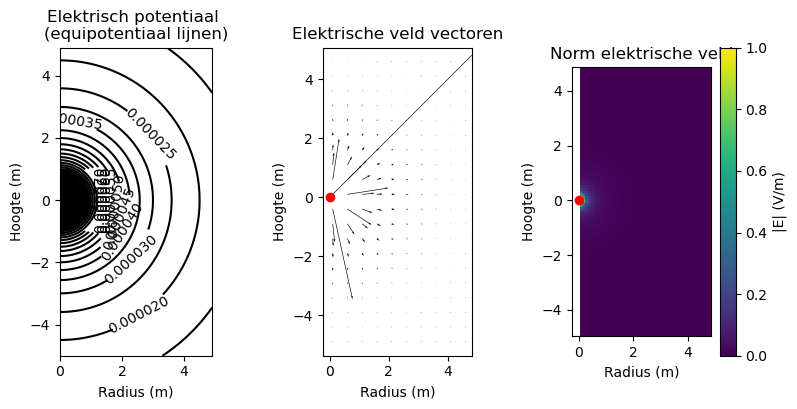

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_8177/2251882138.py:27: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(rTest, VTest, 'r--', label=('Fit voor exponent = ' + str(round(val[0], 3)) + " $\pm$ " + str(round(np.sqrt(cov[0][0]), 3))))


De index van V waar deze maximaal is, en dus overeenkomt met z=0: 51


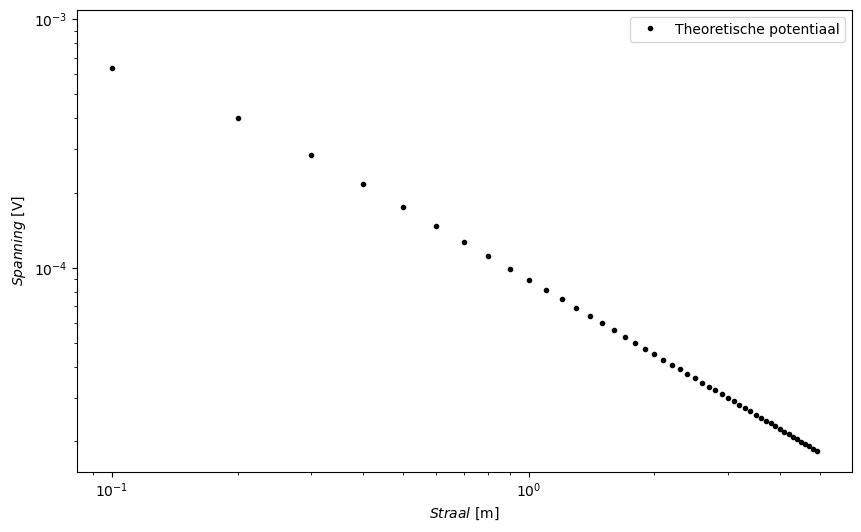

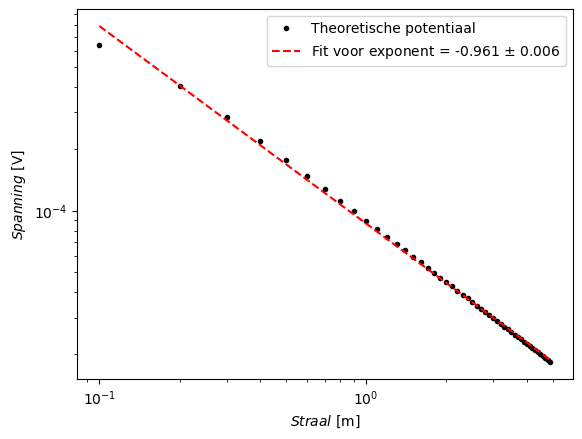

In [3]:
from scipy.optimize import curve_fit

###
# Bepalen welke index overeenkomt met 0 meter door middel van de argmax() functie. Dit komt omdat er een maximum ligt op r=0
z0Pos = np.argmax(V.transpose()[0])
print("De index van V waar deze maximaal is, en dus overeenkomt met z=0:", z0Pos)

# Loglog plot van potentiaal versus straal
# V[51] is de horizontale lijn waarnaar we zoeken
# r geeft de straal
vraag1aPlot = plt.figure(figsize=(10, 6))
plt.loglog(r, V[z0Pos], 'k.', label='Theoretische potentiaal')
plt.xlabel("$Straal$ [m]")
plt.ylabel("$Spanning$ [V]")
plt.legend()
plt.show()

def vraag1aFitFunc(logR, a, b):
    return a * logR + b # Er wordt gefit op een lineaire functie, waardoor alle meetpunten goed meegenomen kunnen worden. Ander kan het voorkomen dat er meetpunten niet correct zwaar gewogen worden

val, cov = curve_fit(vraag1aFitFunc, np.log(r[1:]), np.log(V[z0Pos][1:])) # Voert de lineaire curve fit uit op de exponentiele data door logaritme te nemen, waarbij het eerste punt uitgesloten wordt omdat het NaN is

rTest = np.linspace(r[1], r[-1], 1000)
VTest = np.exp(vraag1aFitFunc(np.log(rTest), val[0], val[1])) # hier worden 'test'-punten genomen waarvoor de gefitte functie bepaald wordt.

plt.loglog(r[1:], V[z0Pos][1:], 'k.', label='Theoretische potentiaal')
plt.plot(rTest, VTest, 'r--', label=('Fit voor exponent = ' + str(round(val[0], 3)) + " $\pm$ " + str(round(np.sqrt(cov[0][0]), 3))))
plt.xlabel("$Straal$ [m]")
plt.ylabel("$Spanning$ [V]")
plt.legend()
plt.show()

###

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_8177/1655800635.py:30: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(rTest, VTest, 'r--', label=('Fit voor exponent = ' + str(round(val[0], 3)) + " $\pm$ " + str(round(np.sqrt(cov[0][0]), 3))))


De index van normE waar deze maximaal is, en dus overeenkomt met z=0: 50


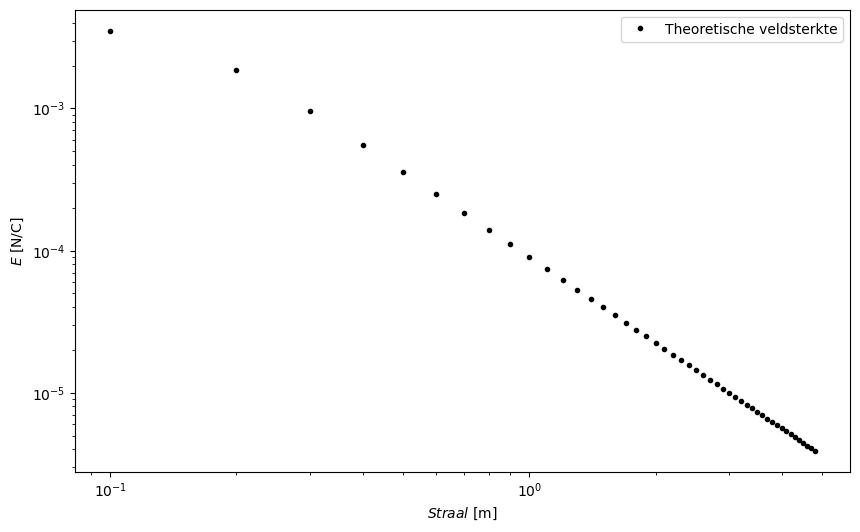

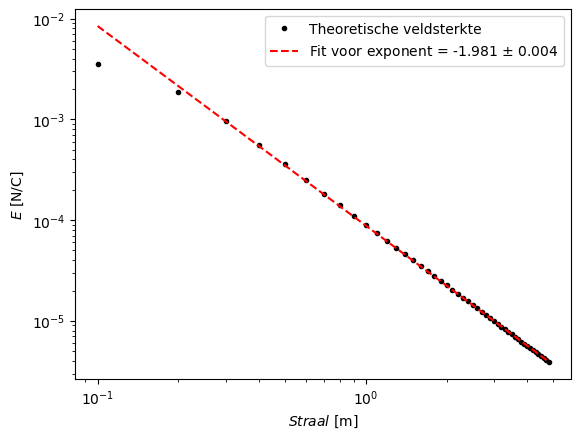

In [4]:
from scipy.optimize import curve_fit

# Hier wordt totaal geen code hergebruikt, het lijkt maar zo.

###

# Bepalen welke index overeenkomt met 0 meter door middel van de argmax() functie. Dit komt omdat er een maximum ligt op r=0
z0Pos = np.argmax(normE.transpose()[0])
print("De index van normE waar deze maximaal is, en dus overeenkomt met z=0:", z0Pos)

# Loglog plot van veldsterkte versus straal
# normE[50] is de horizontale lijn waarnaar we zoeken
# r_for_E geeft de straal
vraag1bPlot = plt.figure(figsize=(10, 6))
plt.loglog(r_for_E, normE[z0Pos], 'k.', label='Theoretische veldsterkte')
plt.xlabel("$Straal$ [m]")
plt.ylabel("$E$ [N/C]")
plt.legend()
plt.show()

def vraag1aFitFunc(logR, a, b):
    return a * logR + b # Er wordt gefit op een lineaire functie, waardoor alle meetpunten goed meegenomen kunnen worden. Ander kan het voorkomen dat er meetpunten niet correct zwaar gewogen worden

val, cov = curve_fit(vraag1aFitFunc, np.log(r_for_E[1:]), np.log(normE[z0Pos][1:])) # Voert de lineaire curve fit uit op de exponentiele data door logaritme te nemen, waarbij het eerste punt uitgesloten wordt omdat het NaN is

rTest = np.linspace(r_for_E[0], r_for_E[-1], 1000)
VTest = np.exp(vraag1aFitFunc(np.log(rTest), val[0], val[1])) # hier worden 'test'-punten genomen waarvoor de gefitte functie bepaald wordt.

plt.loglog(r_for_E, normE[z0Pos], 'k.', label='Theoretische veldsterkte')
plt.plot(rTest, VTest, 'r--', label=('Fit voor exponent = ' + str(round(val[0], 3)) + " $\pm$ " + str(round(np.sqrt(cov[0][0]), 3))))
plt.xlabel("$Straal$ [m]")
plt.ylabel("$E$ [N/C]")
plt.legend()
plt.show()

###

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [5]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

# Voor opdracht 2.g heb ik disk_radius naar 10 veranderd, voor opdracht 3 weer terug naar oorspronkelijke waarde.

[[0.04670257 0.04669585 0.04667637 ... 0.03625655 0.03593352 0.03561154]
 [0.04751702 0.04751    0.04748964 ... 0.03665525 0.03632173 0.03598945]
 [0.04835819 0.04835085 0.04832955 ... 0.03706004 0.03671563 0.03637266]
 ...
 [0.04922731 0.04921963 0.04919735 ... 0.03747094 0.03711522 0.03676118]
 [0.04835819 0.04835085 0.04832955 ... 0.03706004 0.03671563 0.03637266]
 [0.04751702 0.04751    0.04748964 ... 0.03665525 0.03632173 0.03598945]]


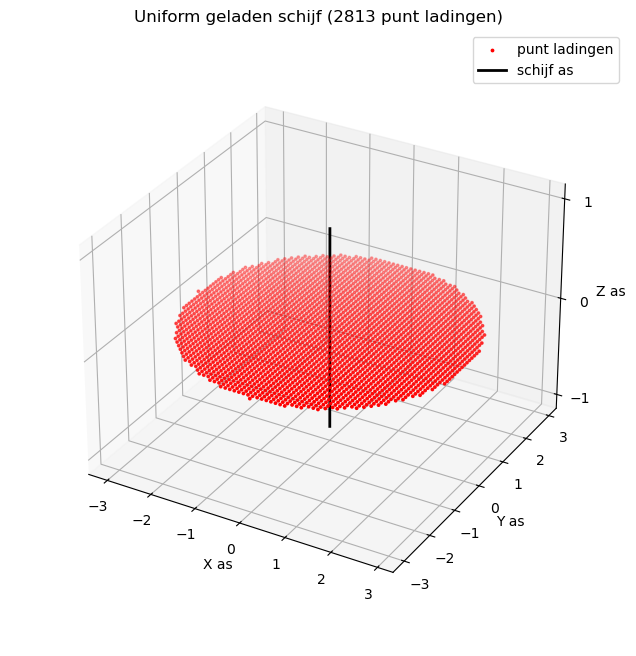

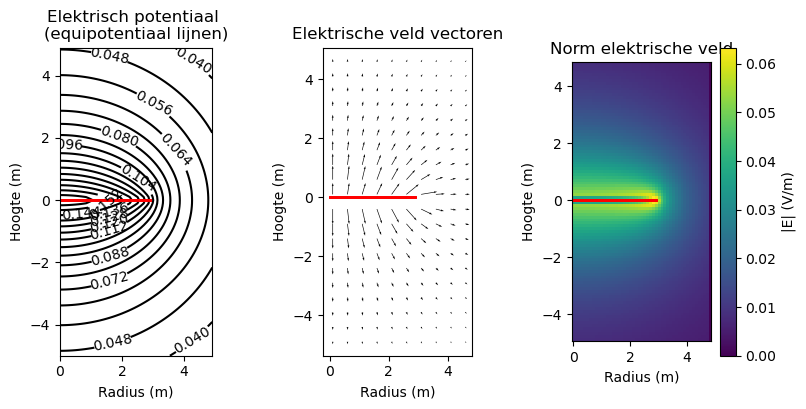

In [6]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

print(V)

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a
1. De disk radius geeft aan hoe breed de schijf waarop de puntladingen gepositioneerd worden moet zijn, en als deze op nul gezet wordt, passen er geen puntladingen in en wordt er niks gesimuleerd.

2. Gridstep geeft aan wat de onderlinge afstand tussen de rasterlijnen moet zijn waarop de puntladingen moeten worden gepositioneerd - het verlagen van de gridstep zorgt voor een fijner raster waardoor er meer puntladingen worden gesimuleerd.

3. We beschouwen de 'V'-variabele. Deze variabele wordt door de functie calculate_V_disk_at_origin_uniform_surface_charge_density gegeven als een tweedimensionale lijst, waarin de potentialen van alle posities in de simulatie gegeven worden. Hiermee wordt de linker plot gemaakt. Van dit potentiaal wordt vervolgens de gradient genomen met de functie compute_E_disk, waarmee de andere plots gemaakt worden.

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [7]:
###
# Theorie: uniforme verdeling betekent \sigma = n * q / A
sigma = round(number_point_charges_on_disk * charge_one_point / (np.pi * disk_radius**2), 16)
print("Ladingsdichtheid sigma:", round(number_point_charges_on_disk * charge_one_point / (np.pi * disk_radius**2), 16), "C/m^2")

# Dit is wel interessant om op te merken: ik neem aan dat sigma idealiter 1e-12 is, maar dat er door de onvolkomenheden in het matchen van de 'grid' en de cirkel wat punten afvallen, 
# waardoor er dus minder ladingen geplaatst worden. Ik verwacht dat als grid size veel lager gezet wordt, dat de ladingsdichtheid dichter bij 1e-12 komt.


###

Ladingsdichtheid sigma: 9.949e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

Text(0, 0.5, 'Potentiaal (V)')

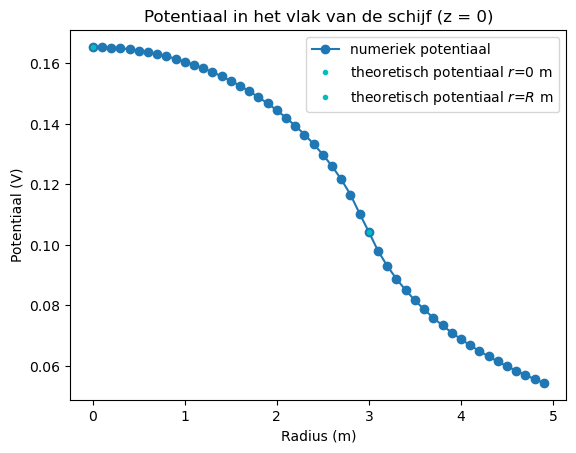

In [8]:
# Vul deze code aan zodat deze vraag 2.3 beantwoordt.
idx_z_zero = np.where(abs(z) < 1e-10)[0][0] # Dit stukje code is eigenlijk best wel slim (geleend)

V_line = V[idx_z_zero, :]                   # potentiaal in het vlak z = 0 als functie van r

V_0 = V_line[0]                             # potentiaal op r = 0

r_R =  disk_radius                          # straal van de schijf
idx_R = np.argmin(abs(r - r_R))
V_R = V_line[idx_R]                         # potentiaal bij r = R

# Testing
# print(V_0)
# print(idx_z_zero)
# V_R = V[idx_z_zero][np.where(abs(r - disk_radius) < 1e-9)[0]] # potentiaal op de straal van de schijf

# Plot
plt.title("Potentiaal in het vlak van de schijf (z = 0)")
plt.plot(r, V_line, "o-", label="numeriek potentiaal")
plt.plot(0, V_0, "c.", label="theoretisch potentiaal $r$=0 m")
plt.plot(r_R, V_R, "c.", label="theoretisch potentiaal $r$=$R$ m")
plt.legend()
plt.xlabel("Radius (m)")
plt.ylabel("Potentiaal (V)")


#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


<function matplotlib.pyplot.show(close=None, block=None)>

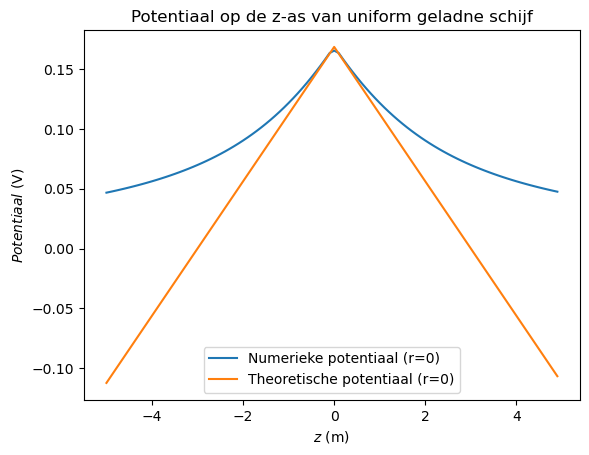

In [9]:
# Numeriek potentiaal op de z-as (r = 0)
V_num = V[:, 0]

# Theoretische potentiaal 
V_theorie = (sigma / (2 * epsilon0)) * (disk_radius - np.abs(z))

plt.figure()
plt.plot(z, V_num, label="Numerieke potentiaal (r=0)")
plt.plot(z, V_theorie, label="Theoretische potentiaal (r=0)")
plt.xlabel("$z$ (m)")
plt.ylabel("$Potentiaal$ (V)")
plt.title("Potentiaal op de z-as van uniform geladne schijf")
plt.legend()

plt.savefig("2d_plot", dpi=300)
plt.show

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

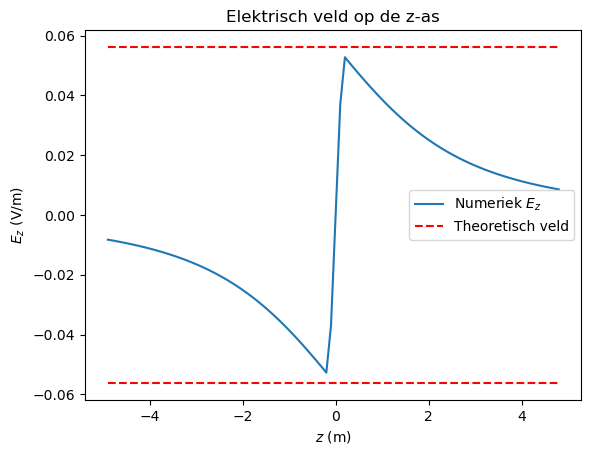

In [10]:
# Numeriek elektrische veld op de z-as (r=0)
Ez_num = Ez[:, 0]
z_E = z[1:-1]

# Theoretische veld voor een oneindig geladen oppervlak
E_theorie = sigma / (2*epsilon0)

# Plot
plt.figure()
plt.plot(z_E, Ez_num, label="Numeriek $E_z$")
plt.plot(z_E, E_theorie * np.ones_like(z_E), "r--", 
         label="Theoretisch veld")
plt.plot(z_E, -E_theorie * np.ones_like(z_E), "r--")
plt.xlabel("$z$ (m)")
plt.ylabel("$E_z$ (V/m)")
plt.title("Elektrisch veld op de z-as")
plt.legend()

plt.savefig("2e_plot.png", dpi=300)
plt.show()


#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f


1. Het elektrische veld van een uniform geladen schijf benadert dat van een oneindig geladen plaat dichtbij het centrum van de schijf (r ≈ 0) en (R >> z), dus wanneer de straal van de schijf groter is vergeleken met de afstand tot het meetpunt.
2.  1. Bij de numerieke neemt het veld af (wordt zwakker) als |z| groter wordt vergeleken met een theoretische, waar het overal constant is. Dit is omdat het een eigenlijk een eindige schijf is dan een oneindige theoretische plaat, waardoor het op grotere afstanden zich zou gedragen als een puntlading dan een plaat.
    2. Ook is het opvallend dat er een sprong van de positieve end naar de negatieve end is rond z=0, wat te verklaren is doordat het veld van richting verandert als je boven of onder het schijf bevindt.

#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

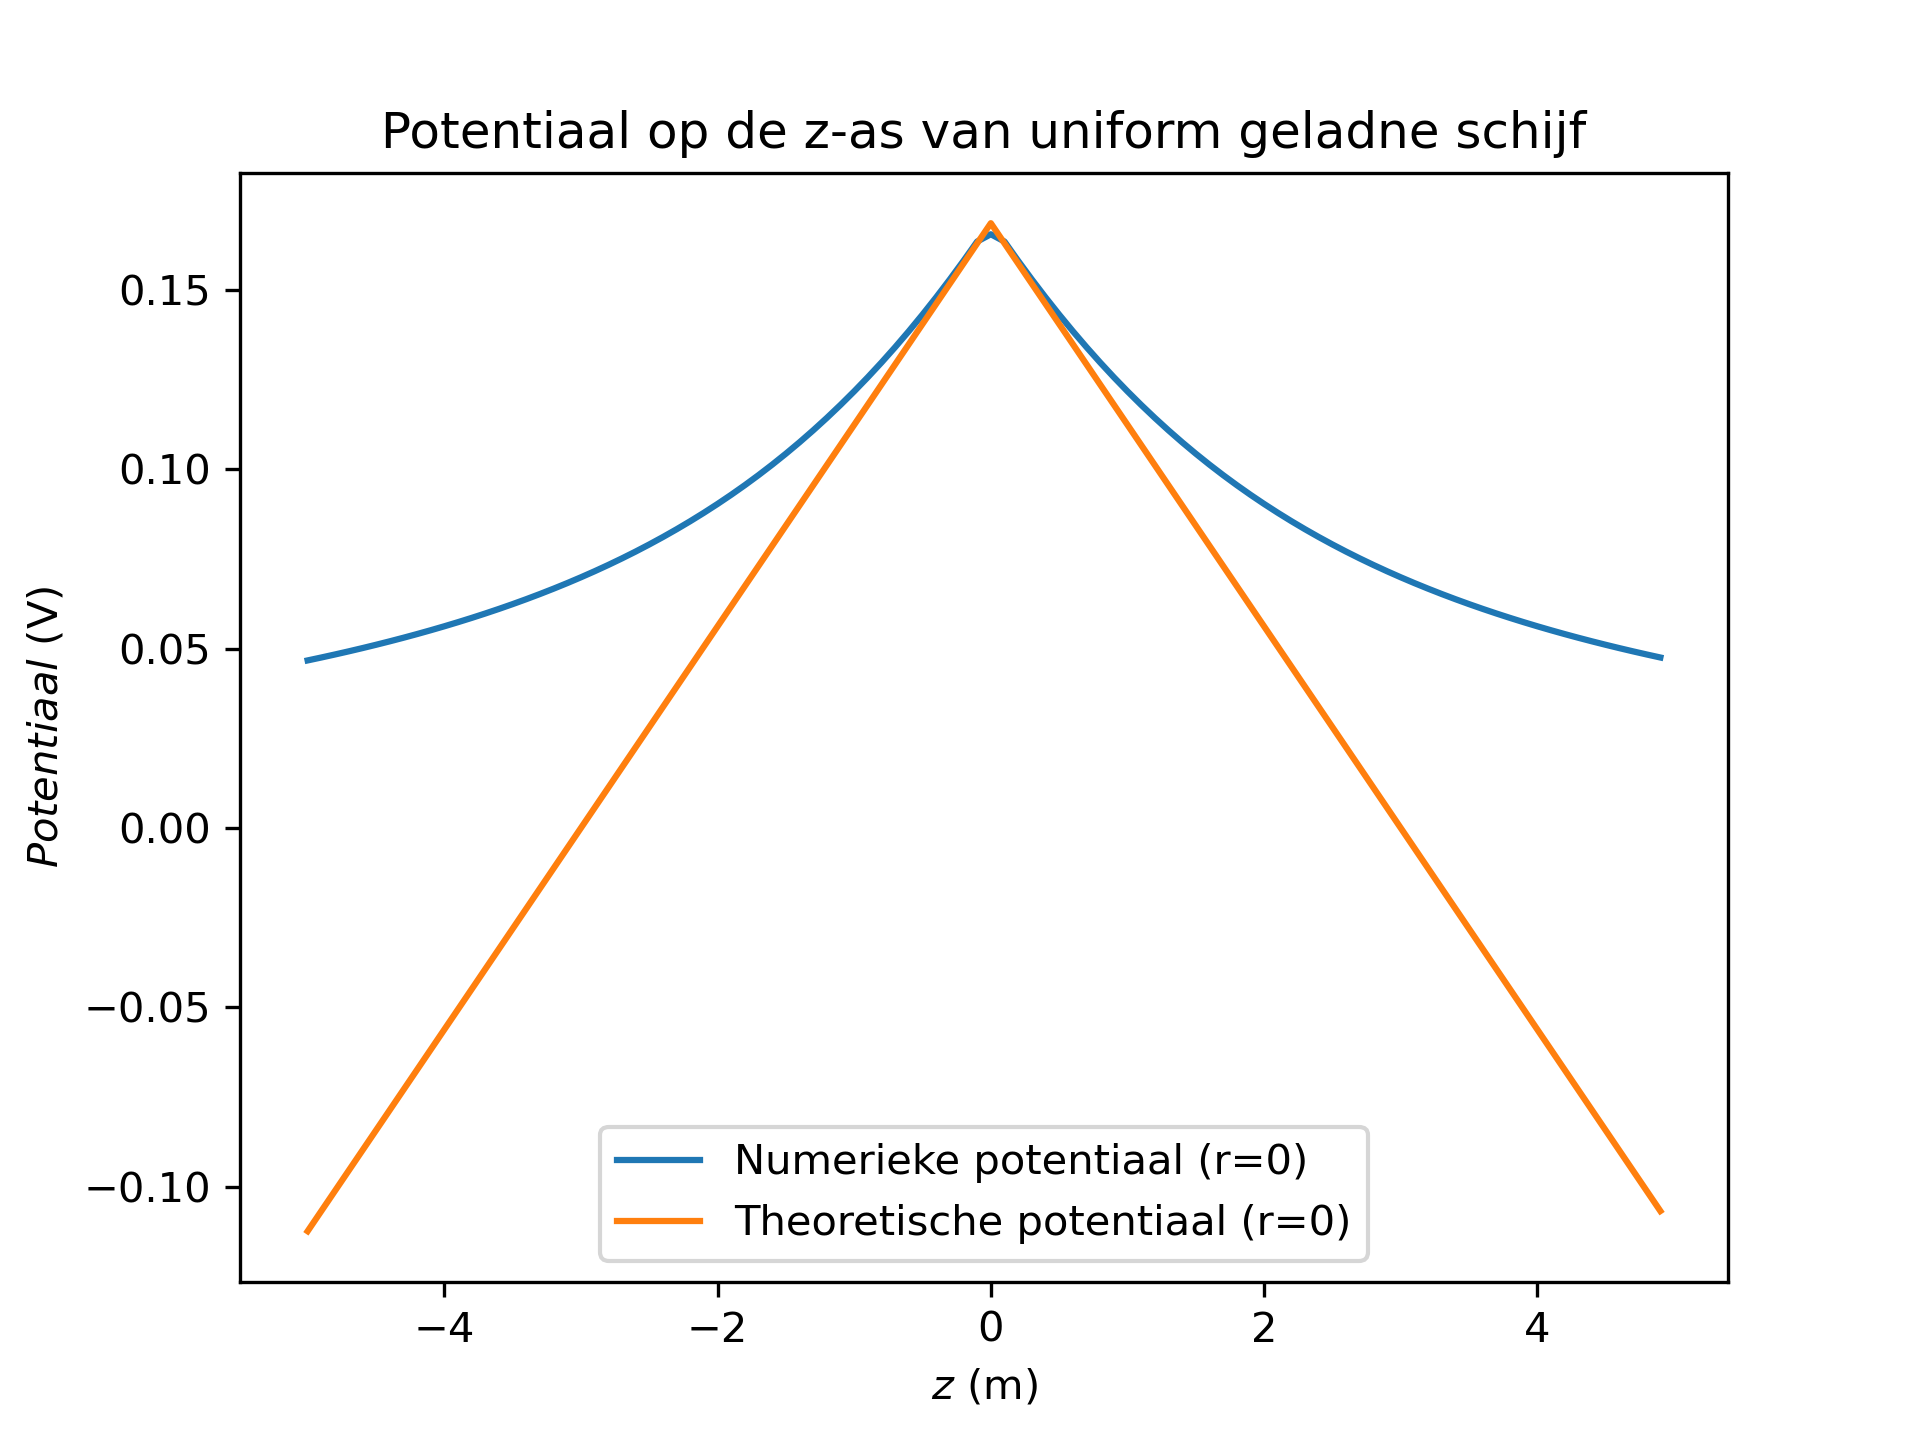

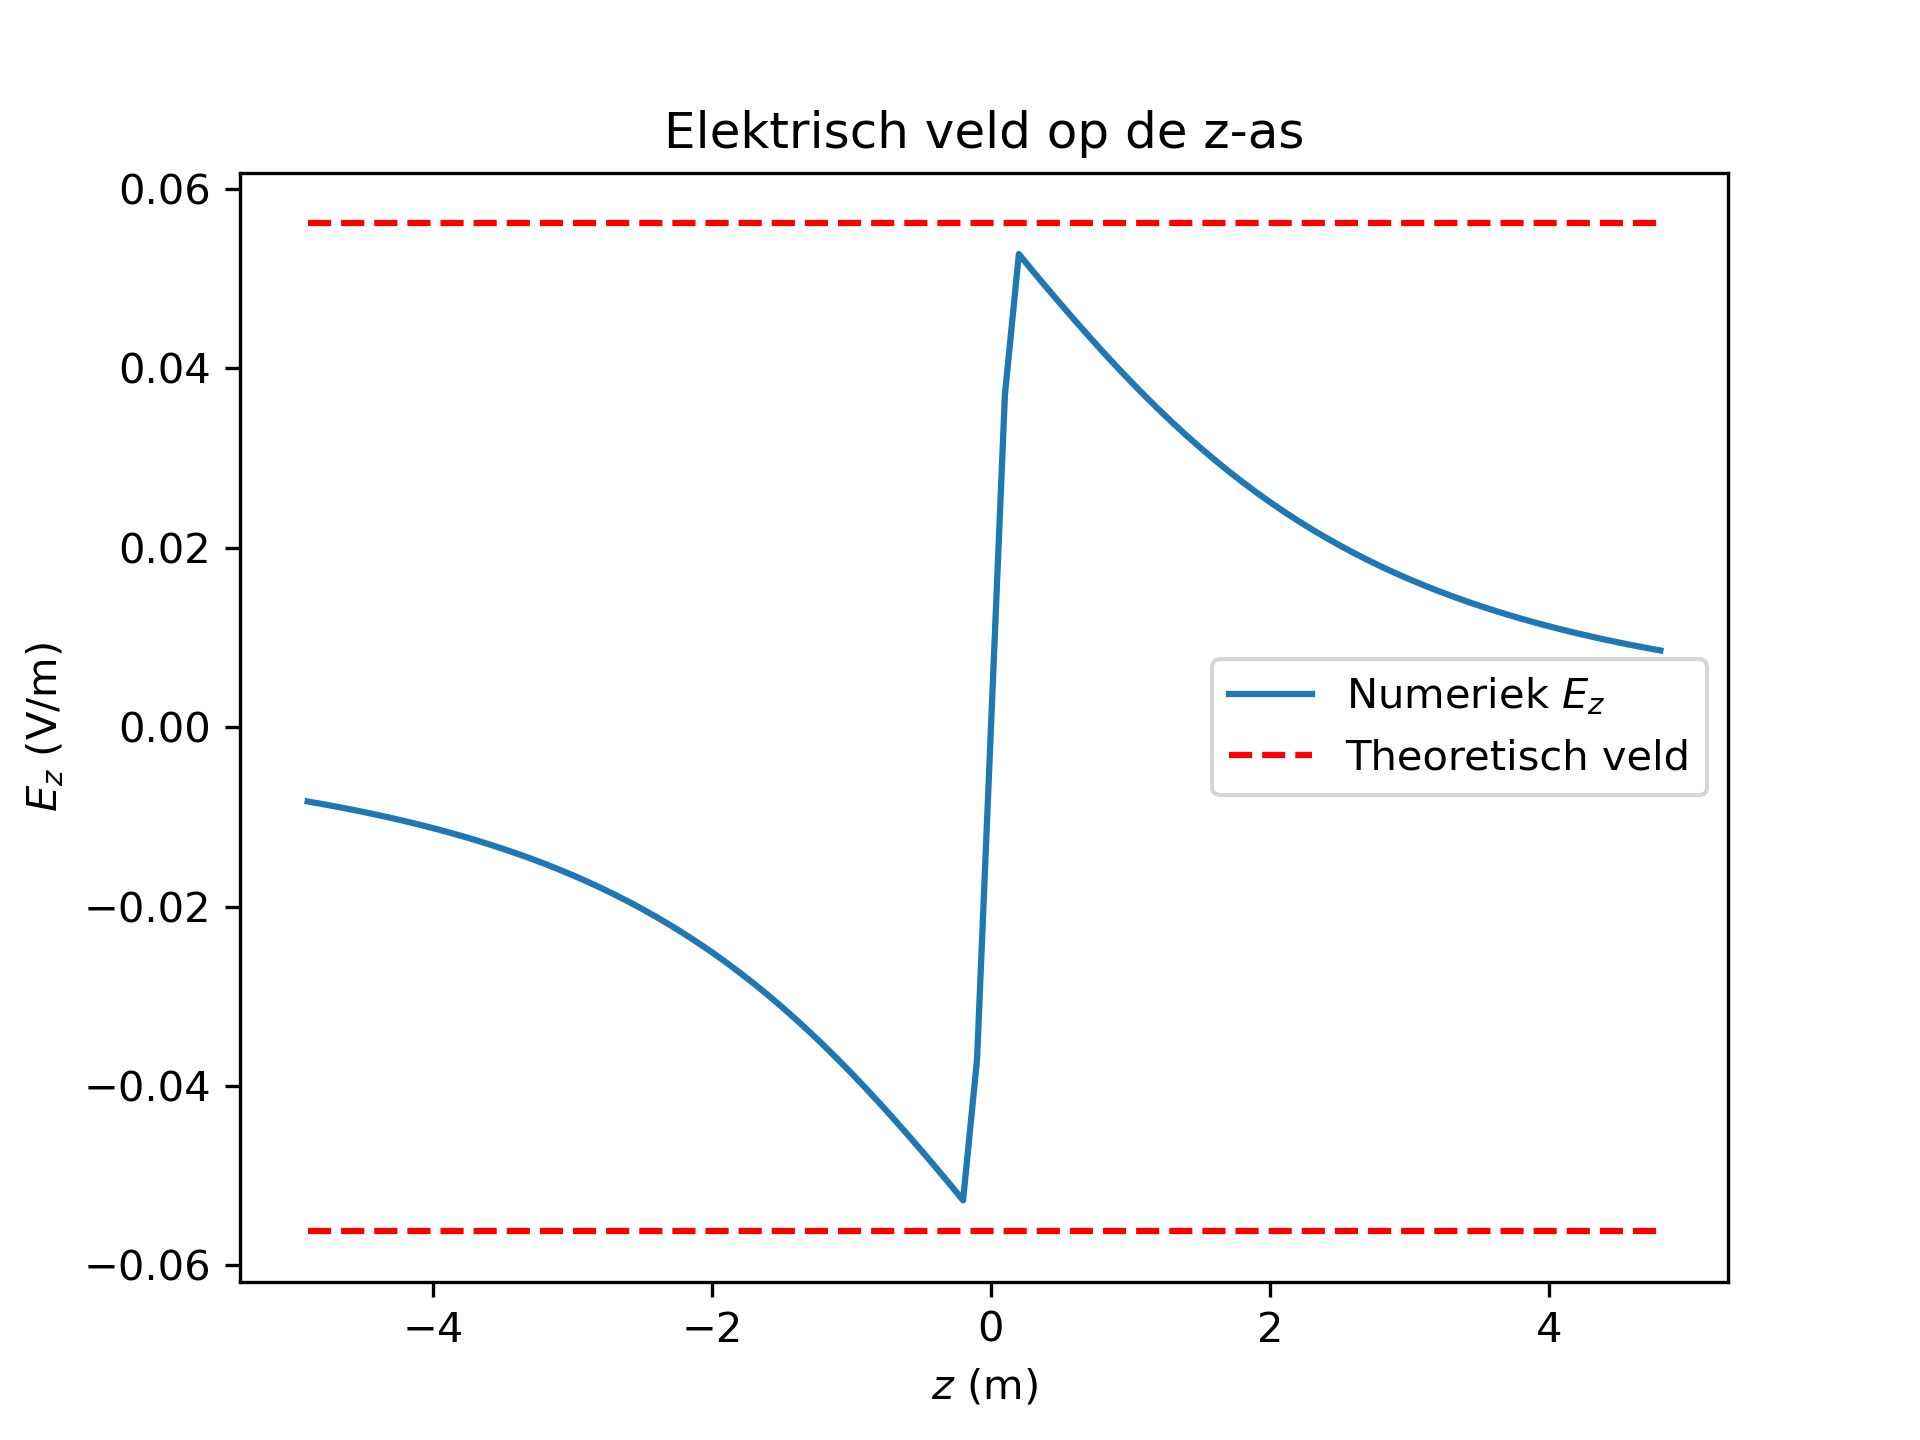

In [11]:
###
###Jouw code hier###
###
display(Image("2d_plot.png"))
display(Image("2e_plot.png"))

##### Antwoorden 2g

1. Het is opmerkelijk dat bij het vergroten van de straal (in dit geval r=10) dat de numerieke potentiaal beter de theoretische lijn volgt, dit is mogelijk te verklaren doordat het 'meer' als een oneindige geladen oppervlak gedraagt.
2. Ook volgt er bij een vergroting dat het numerieke veld vlakker worden en beter de theoretische waarde nadert (σ/(2ϵ0​)).

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

We zoeken \(z\) zodat \(E(z) = 0.1\,E_\infty\) voor een uniform geladen schijf.  

$$
\mathbf{E}(z) = \frac{\sigma}{2\epsilon_0} \left[ 1 - \frac{z}{\sqrt{R^2 + z^2}} \right] \hat{\mathbf{z}}, \quad
E_{theorie} = \frac{\sigma}{2\epsilon_0}
$$

We willen 10% van de theoretische oneindige geladen plaat:

$$
E(z) = 0.1E_{theorie}
$$

$$
1 - \frac{z}{\sqrt{R^2 + z^2}} = 0.1 \;\Rightarrow\; \frac{z}{\sqrt{R^2 + z^2}} = 0.9
$$

$$
z^2 = 0.9^2 (R^2 + z^2) \;\Rightarrow\; z^2 (1-0.81) = 0.81 R^2 \;\Rightarrow\; z^2 \approx 4.2632 R^2
$$

$$
\boxed{z \approx 2.07 \, R}
$$

Dus het veld is 10% van dat van een oneindige palat rond z ≈ 2.07R



### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

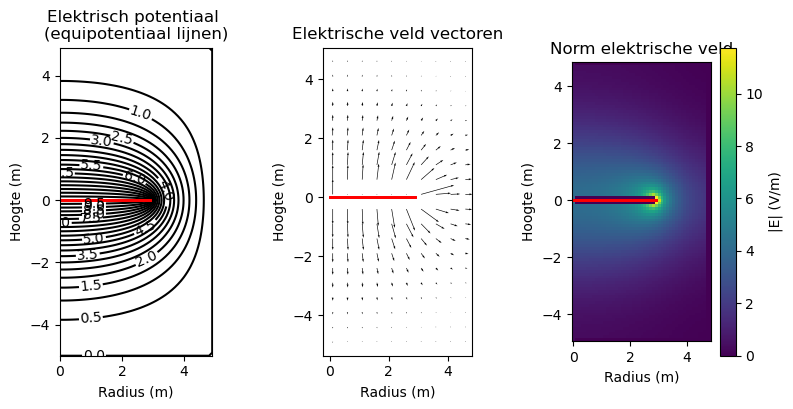

In [12]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

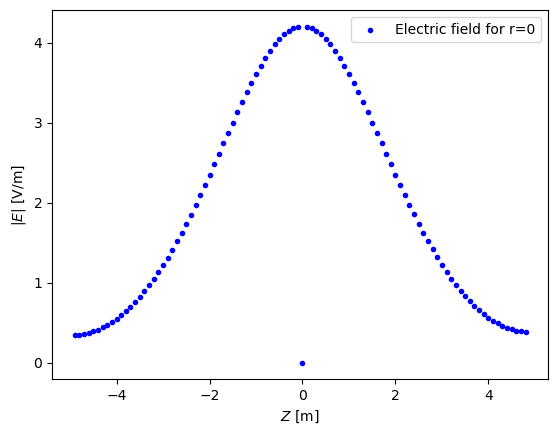

De norm van het elektrische veld nabij z=0 is 4.202 V/m


In [13]:
###
r0ElectricField = normE.transpose()[0] # Neemt alle waarden op r=0

plt.scatter(z_for_E, r0ElectricField, color='blue', marker='.', label="Electric field for r=0")
plt.xlabel("$Z$ [m]")
plt.ylabel("$|E|$ [V/m]")
plt.legend()
plt.show()

print("De norm van het elektrische veld nabij z=0 is", round(max(r0ElectricField), 3), "V/m")

###

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

E = $\frac{\sigma}{\epsilon_0}$

Dit kan herschreven worden:
$\sigma = {\epsilon}_0 E$

In [14]:
#### Print met deze cel met een nette opmaak je antwoord op vraag 3b 2.
# Je kan zeer dicht bij de schijf aannemen dat dit een oneindig plat vlak is, waardoor de formule E = \sigma / \epsilon 0 opgaat. Dus: sigma = epsilon0 * E

sigma = max(r0ElectricField) * epsilon0

print("Oppervlaktelading nabij r=0, z=0:", round(sigma, 14), "C/m^2")

Oppervlaktelading nabij r=0, z=0: 3.72e-11 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


Oppervlaktelading nabij r, z = 0 voor geleidende schijf: 3.72e-11 C/m^2
Oppervlaktelading nabij r, z = 0 voor uniform verdeelde schijf: 7.441e-11 C/m^2


<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8177/3204173991.py:23: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma$ [C/m$^2$]")
/tmp/ipykernel_8177/3204173991.py:15: RuntimeWarning: divide by zero encountered in divide
  return Q / (2 * np.pi * R * np.sqrt(R**2 - r**2))


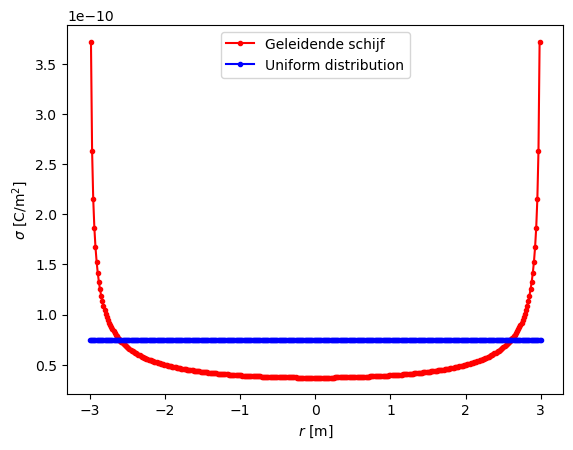

In [15]:
###

# sigma(r) = Q / (2 pi R sqrt(R^2 - r^2)) -----> Q = sigma * 2 pi R sqrt (R^2 - r^2) ---->r^2 = 0 voor r=0 ---> Q = sigma * 2 pi R^2

Q_tot = sigma * 2 * np.pi * disk_radius**2

sigma_uniform_distribution = Q_tot / (np.pi * disk_radius**2)

print("Oppervlaktelading nabij r, z = 0 voor geleidende schijf:", round(sigma, 14), "C/m^2")
print("Oppervlaktelading nabij r, z = 0 voor uniform verdeelde schijf:", round(sigma_uniform_distribution, 14), "C/m^2")

# Note: dit is exact twee keer zoveel

def oppervlakteLading(r, Q, R):
    return Q / (2 * np.pi * R * np.sqrt(R**2 - r**2))

r_test = np.linspace(-disk_radius, disk_radius, 400) # 400 is genoeg punten

plt.plot(r_test, oppervlakteLading(r_test, Q_tot, disk_radius), color='red', marker='.', label="Geleidende schijf")
plt.plot(r_test, np.full(len(r_test), sigma_uniform_distribution), color='blue', marker='.', label="Uniform distribution")
plt.legend()
plt.xlabel("$r$ [m]")
plt.ylabel("$\sigma$ [C/m$^2$]")
plt.show()

###

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [16]:
# Deze cel kan je gebruiken om van vraag 3c 1 tot en met 4 te beantwoorden.
# Maximum elektrisch veld:
print("Maximum elektrisch veld:", round(np.max(normE), 3), "V/m")

# Waar zit'ie? 

maximumIndex = np.unravel_index(np.argmax(normE, keepdims=True), np.shape(normE))


print("Maximum E-veld zit op z =", round(z[maximumIndex[0][0][0]], 8), ", r =", round(r[maximumIndex[1][0][0]], 8), "m")

# Hoeveel keer sterker?

r0z0ElectricField = max(r0ElectricField)

print("Het maximale E-veld is", round((normE[maximumIndex[0][0][0]][maximumIndex[1][0][0]])/r0z0ElectricField, 3), "keer sterker op de randen dan in het midden")


Maximum elektrisch veld: 11.753 V/m
Maximum E-veld zit op z = -0.0 , r = 2.9 m
Het maximale E-veld is 2.797 keer sterker op de randen dan in het midden


##### Antwoord 3d.5

Doordat de ladingen vrij zijn te bewegen en gelijke ladingen hebben, duwen ze elkaar opzij. Daardoor duwen ze elkaar tegen de randen aan, waar ze niet verder kunnen. Hierdoor ontstaat daar een hoge dichtheid aan ladingen, waardoor er daar ook een sterk elektrisch veld ontstaat.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

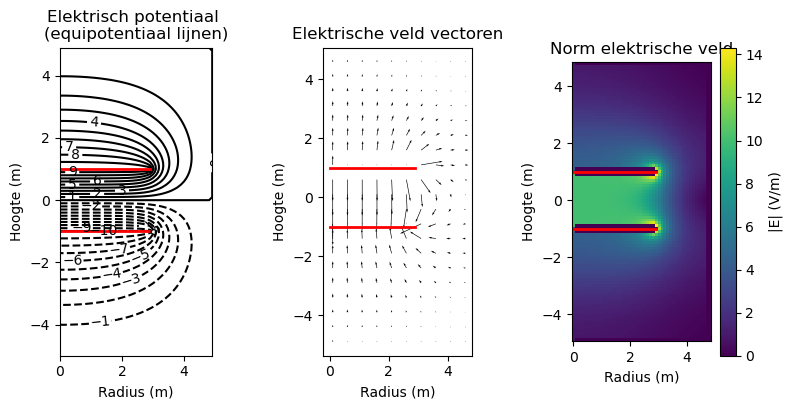

In [17]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


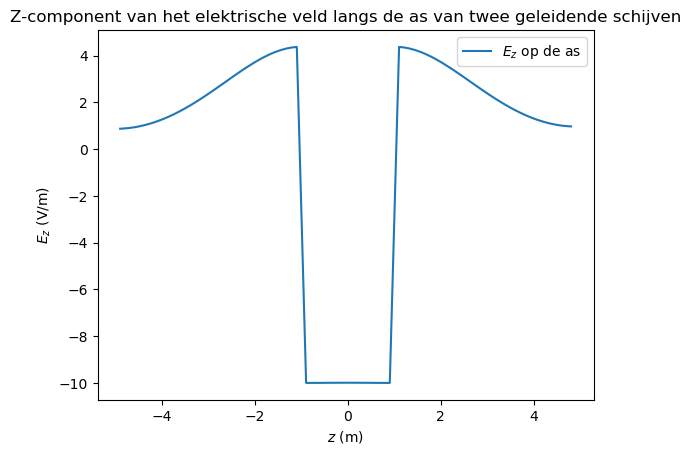

In [18]:
# Numeriek Ez langs de as van de schijven (r=0)
Ez_on_axis = Ez[:, 0]
z_axis = z[1:-1]  # bijbehorende z-waarden

plt.figure()
plt.plot(z_axis, Ez_on_axis, label="$E_z$ op de as")
plt.xlabel("$z$ (m)")
plt.ylabel("$E_z$ (V/m)")
plt.title("Z-component van het elektrische veld langs de as van twee geleidende schijven")
plt.legend()
plt.show()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

1. 
Voor twee parallelle geleidende platen met potentiaalverschil \(V = V_1 - V_2\) en afstand \(d\):

$$
E_z = -\frac{dV}{dz} = \frac{V_1 - V_2}{d}
$$

- Tussen de platen (homogeen gebied): het veld is constant, wijst van de positieve naar de negatieve plaat.  
- Buiten de platen (randeffecten): het veld neemt af en is niet homogeen.  

*Schets van de regio's:*

$$
\begin{array}{c}
V_1 \\
\hline
\text{homogeen } E \\
\hline
V_2
\end{array}
$$

2.  
- Het numerieke \(E_z\) langs de as is vrijwel constant tussen de platen, zoals theoretisch verwacht.  
- Dicht bij de randen neemt het veld af door rand-effecten.

3. 
- Voor 1 schijf neemt langs het veld de as af met de afstand en is het beperkt tot 1 kant, terwijl het voor twee platen het veld tussen de platen constant en homogeen is, wat ookwel een uniform veld is.

Voordeel: een stabiel, uniform elektrisch veld is nuttig voor toepassingen waar een constante veldsterkte vereist is.

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [19]:
###
###your code here###
###

# Gegeven waarden
V_diff = V1 - V2  # potentiaalverschil tussen de platen
A = np.pi * disk_radius**2  # oppervlak van een schijf

# 1. Verwachte oppervlakte lading op een schijf
sigma_plate = epsilon0 * V_diff / spacing_between_disks  # C/m^2

# 2. Verwachte totale lading op beide schijven
Q_one_plate = sigma_plate * A
Q_total = Q_one_plate * 2

# 3. Capaciteit
C = Q_one_plate / V_diff  # C = Q / V

print(f"Oppervlakte lading op een schijf: {sigma_plate:.4e} C/m^2")
print(f"Totale lading op beide schijven: {Q_total:.4e} C")
print(f"Capaciteit van het systeem: {C:.4e} F")

Oppervlakte lading op een schijf: 8.8540e-11 C/m^2
Totale lading op beide schijven: 5.0068e-09 C
Capaciteit van het systeem: 1.2517e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

1.
De oppervlaktelading aan de buitenkant van een geleidend schijf is 0, omdat de schijven zich in een parallelle platen-configuratie bevinden met gelijke en tegengestelde ladingen aan de binnenkanten, waardoor het elektrisch veld buiten de schijven worden gecompenseerd door de ladingen aan de tegenoverliggende plaat, waaruit er dan geen netto ladingsdichtheid aan de buitenzijde van de schijven zijn.

Kortom alle ladingen bevinden zich aan de binnenzijde van de platen die naar elkaar gericht zijn.

2.
<!-- - Het elektrische veld direct buiten het oppervlak van een geleider staat altijd loodrecht op het oppervlak.   -->
De grootte van het veld vlakbij een plat oppervlak wordt gegeven door:

$$
|\mathbf{E}| = \frac{\sigma}{\epsilon_0}
$$

waarbij sigma de lokale oppervlakteladingdichtheid is.  

Voor een perfect plat, homogeen geladen oppervlak (zoals hier tussen de platen) is het veld constant en wijst het van de positieve naar de negatieve plaat.

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [20]:
###
###Your code here###
###

# Ez net onder en net boven de onderste schijf (r=0)
Ez_below = Ez[idx_z2-1, 0]  # vlak onder de onderste plaat
Ez_above = Ez[idx_z2+1, 0]  # vlak boven de onderste plaat

# Ladingsdichtheid via sigma = epsilon0 * E
sigma_below = epsilon0 * Ez_below
sigma_above = epsilon0 * Ez_above

print(f"Ez vlak onder de plaat: {Ez_below:.4e} V/m geeft sigma_below: {sigma_below:.4e} C/m^2")
print(f"Ez vlak boven de plaat: {Ez_above:.4e} V/m geeft sigma_abovr: {sigma_above:.4e} C/m^2")

Ez vlak onder de plaat: -2.8100e+00 V/m geeft sigma_below: -2.4880e-11 C/m^2
Ez vlak boven de plaat: -1.0003e+01 V/m geeft sigma_abovr: -8.8570e-11 C/m^2


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

*Beantwoord vraag 4f in deze cel.*

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [21]:
def vlakkeplaat(A, d, epsilonZero):
    C = (A * epsilonZero) / d # Afkomstig van 2.54
    return C

def cilinder(L, straalBinnen, straalBuiten, epsilonZero):
    C = (2 * np.pi * epsilonZero * L) / (np.log(straalBuiten / straalBinnen)) # Deze is afkomstig van zelf berekenen
    return  C


#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [22]:
###
epsilonZeroAir = 8.854e-12 # Gegeven
epsilonZeroWater = 80 * epsilonZeroAir
epsilonZeroPVC = 3.5 * epsilonZeroAir

#1
print("Capacity of two plates 10x10 cm, 1mm spacing, air medium:", vlakkeplaat(0.01, 1e-3, epsilonZeroAir), "F")

#2
print("Capacity of cylindrical capacitor 9mm, 10mm, L=10cm, air:", round(cilinder(0.1, 9e-2, 10e-2, epsilonZeroAir), 14), "F")


#3
print("Capacity of two plates 10x10 cm, 2mm spacing, air medium:", vlakkeplaat(0.01, 2e-3, epsilonZeroAir), "F")


# Hier is de aanname gedaan dat de binnendiameter verkleint
print("Capacity of cylindrical capacitor 8mm, 10mm, L=10cm, air:", round(cilinder(0.1, 8e-2, 10e-2, epsilonZeroAir), 14), "F")


#4
print("Capacity of two plates 10x10 cm, 1mm spacing, water medium:", round(vlakkeplaat(0.01, 1e-3, epsilonZeroWater), 14), "F")

print("Capacity of cylindrical capacitor 9mm, 10mm, L=10cm, water:", round(cilinder(0.1, 9e-2, 10e-2, epsilonZeroWater), 14), "F")


# 5
print("Capacity of two plates 10x10 cm, 1mm spacing, PVC medium:", vlakkeplaat(0.01, 1e-3, epsilonZeroPVC), "F")

print("Capacity of cylindrical capacitor 9mm, 10mm, L=10cm, PVC:", round(cilinder(0.1, 9e-2, 10e-2, epsilonZeroPVC), 14), "F")


###


Capacity of two plates 10x10 cm, 1mm spacing, air medium: 8.854e-11 F
Capacity of cylindrical capacitor 9mm, 10mm, L=10cm, air: 5.28e-11 F
Capacity of two plates 10x10 cm, 2mm spacing, air medium: 4.427e-11 F
Capacity of cylindrical capacitor 8mm, 10mm, L=10cm, air: 2.493e-11 F
Capacity of two plates 10x10 cm, 1mm spacing, water medium: 7.0832e-09 F
Capacity of cylindrical capacitor 9mm, 10mm, L=10cm, water: 4.22407e-09 F
Capacity of two plates 10x10 cm, 1mm spacing, PVC medium: 3.0989e-10 F
Capacity of cylindrical capacitor 9mm, 10mm, L=10cm, PVC: 1.848e-10 F


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [23]:
###
def inverseCilinder(C, straalBinnen, straalBuiten, epsilonZero):
    # C = (2 * np.pi * epsilonZero * L) / (np.log(straalBuiten / straalBinnen)) # Deze is afkomstig van zelf berekenen

    return (C * np.log(straalBinnen / straalBuiten)) / (2 * np.pi * epsilonZero)

def inverseVlakkePlaat(C, d, epsilonZero):
    # C = (A * epsilonZero) / d # Afkomstig van 2.54
    return (C * d) / epsilonZero

print("Lengte cilindrische condensator:", round(inverseCilinder(1e-6, 6e-3, 5e-3, epsilonZeroAir), 1), "meter")

print("Lengte vlakke plaat condensator breedte=6mm:", round(inverseVlakkePlaat(1e-6, 0.5e-3, epsilonZeroAir)/6e-3, 1), "meter")


# Dit doet vermoeden dat er in een elektrolytische condensator een.. elektrolyt zit. Dit zorgt voor een veel hogere epsilonZero, waardoor er minder wikkelingen nodig zijn (want een elco zit opgewikkeld volgens mij)
# Tevens zijn de afstanden in een elco niet 0.5mm maar veel kleiner
###

Lengte cilindrische condensator: 3277.3 meter
Lengte vlakke plaat condensator breedte=6mm: 9411.9 meter


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d


    Natuurlijk is het realistisch dat mijn condensator negen kilometer lang is, gebeurt dat niet elke dag? Nee. De resultaten zijn volkomen onrealistisch omdat verkeerde aannames bevatten.
    Dit heb ik zojuist toevallig bedacht! Zie het stuk code hierboven, maar het is dus dat er een elektrolyt in zit, de afstand niet 0.5mm is en ze de vlakke plaat oprollen


#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [24]:
###
# Ooh, hier wordt dicht bij huis gewerkt - samen met Boas Bakker en Wim Bouwman ben ik een artikel aan het schrijven over de mechanica van de attracties in Drievliet - dus we hebben data hierover!
# Het blijkt dat de massa van het karretje intens lastig te gokken is, omdat deze overal uitdeelt - het beste zou je hem kunnen bepalen door de achtbaan een paar keer te doorlopen met verschillende massa's
# aan mensen en dan de systematische fout (massa karretje) te meten, maar dit is nagenoeg onmogelijk

# 1. We schatten dat het karretje 1000 kilo weegt.

# We kunnen hier simpelweg 1/2 mv^2 gebruiken, maar dat is saai. We hebben in ons artikel een prachtige grafiek staan (dubbel geintegreerde acceleratie met geintegreerde gyroscoop en heel veel automatische correctie)
# waarin wij kunnen aflezen dat na de lancering de kinetisch energie 140 J / kg bedraagt.

# Dit geeft trouwens ongeveer 60 km/u, dus drievliet blaast een beetje haar getallen op (of onze acceleromters zijn niet zo accuraat)

# 2. 140 J / kg --> 140 KJ

# E = 0.5 CV^2 --> C = 2E / V^2
# 3. C = 280000 / 10000^2 = 0.0028 F = 2.8 millifarad

# 4.

print("Oppervlakte vlakke plaat condensator drievliet:", round(inverseVlakkePlaat (2.8e-3, 1e-3, epsilonZeroWater)), "m^2")

# 6. In de cell hieronder
###

Oppervlakte vlakke plaat condensator drievliet: 3953 m^2


##### Antwoorden 5e

Dit is prima mogelijk: er stond een 40ft-scheepscontainer die de condensator bevatte. Deze heeft als interne afmetingen 12.03 meter bij 2.35 meter bij 2.39 meter, wat dus een intern volume geeft van 67.57 m^3. Er vanuit gaande dat de platen 1e-3 meter van elkaar verwijderd zijn, passen er dus in een 40ft-scheepscontainer 67570 m^2 aan vlakke platen. Dit is meer dan genoeg om de ongeveer vierduizend vierkante meter aan vlakke plaat te bevatten.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

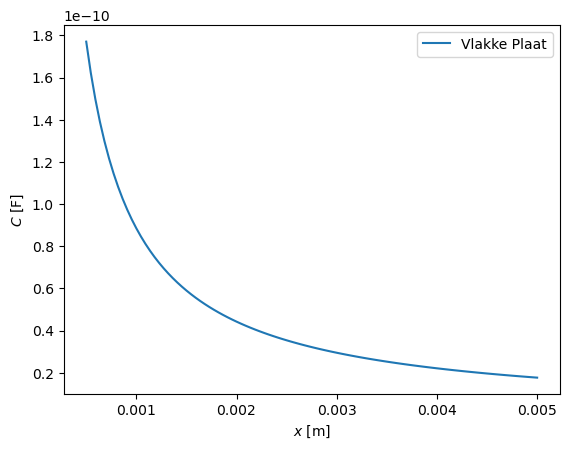

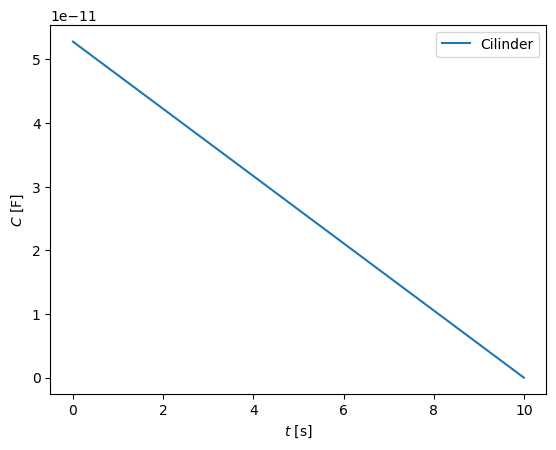

In [25]:


###
# Aangenomen wordt dat alles in lucht gebeurt

# 1.

distances = np.linspace(0.5e-3, 5e-3, 100)
capacitiesVlakkePlaat = vlakkeplaat(0.01, distances, epsilonZeroAir)

plt.plot(distances, capacitiesVlakkePlaat, label='Vlakke Plaat')
plt.xlabel("$x$ [m]")
plt.ylabel("$C$ [F]")
plt.legend()
plt.show()

times = np.linspace(0, 10, 100)
lengthsFromTimes = 0.1 - 0.01*times # Tijden omzetten in lengten
capacitiesCyclindrical = cilinder(lengthsFromTimes, 9e-3, 10e-3, epsilonZeroAir)

plt.plot(times, capacitiesCyclindrical, label='Cilinder')
plt.xlabel("$t$ [s]")
plt.ylabel("$C$ [F]")
plt.legend()
plt.show()
###



## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/Condensator_1_uF.jpg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

![image](20260302_210420.jpg)

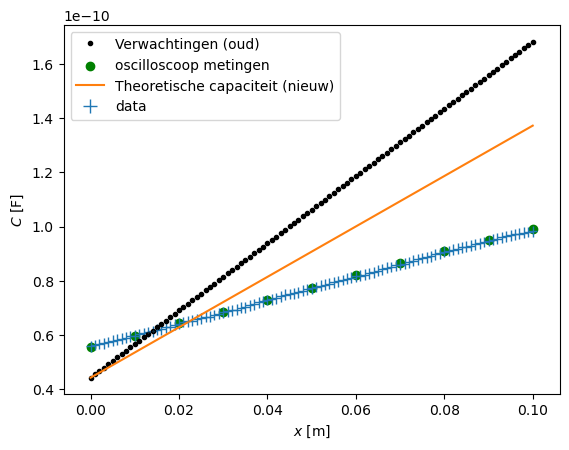

In [26]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
def condensator_extra_laag(L, dTot, wijdte, schuifafstand, schuifdikte, Erlucht, Erpvc): # Schrijf hier jouw functie
    C = (L**2 * epsilon0) * ((L**2 * dTot - wijdte * schuifafstand * schuifdikte) * Erlucht + (wijdte * schuifafstand * schuifdikte) * Erpvc) / (L**2 * dTot**2)

    return C


sTest = np.linspace(0, 100e-3, 101) # Afstanden waarmee de schuif in de condensator geschoven was

condensatorL = 100e-3 # 100 millimeter zijden
condensatorDTot = 2e-3 # ongeveer 2mm afstand tussen platen
schuifWijdte = 80e-3 # Schuif is 80mm breed
schuifDikte = 1.5e-3 # Schuif is 1.5mm dik

ErLucht = 1.0
ErPVC = 4.5


CTest = condensator_extra_laag(condensatorL, condensatorDTot, schuifWijdte, sTest, schuifDikte, ErLucht, ErPVC)

##### Uit andere code voor kalibratie en metingen

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
afstanden = np.linspace(0,100,101)*1e-3
capaciteiten = np.array([55.9,56.3,56.7,57.0,57.4,57.9,58.3,58.6,59.0,59.5,59.8,60.3,60.7,61.1,61.4,61.9,62.1,62.9,63.1,63.8,64.2,64.8,65.0,65.3,65.8,66.2,66.7,66.8,67.4,67.8,68.4,68.7,69.1,69.3,70.0,70.3,70.9,71.3,72.0,72.5,72.9,73.2,73.6,74.3,74.8,75.1,75.4,75.8,76.4,76.8,77.3,77.7,78.2,78.6,79.0,79.4,79.8,80.3,80.8,81.2,81.7,81.8,82.2,82.7,83.2,83.7,84.3,84.8,85.1,85.7,86.0,86.3,86.9,87.4,87.9,88.4,88.7,89.0,89.7,90.1,90.8,91.0,91.5,91.9,92.3,92.5,93.0,93.4,93.9,94.3,94.7,95.1,95.5,96.0,96.4,96.8,97.1,97.4,97.8,98.0,98.2]) *1e-12
oscilloscoopMetingen = np.array([55.4, 59.6, 64.3, 68.6, 73.0, 77.5, 82.1, 86.6, 91.0, 95.0, 99.0]) * 1e-12

#total area in capacitor
A_tot = 0.01
x = (np.linspace(0,100,101)*1e-3)

er_lucht = 1.0
er_pvc = 4.5


def c_from_x(x, Er):
    A_pvc = (8e-2)*x
    A_air = A_tot-A_pvc
    C = ((A_pvc*Er+A_air*er_lucht) * epsilon0) / condensatorDTot
    return C

popt,pcov = curve_fit(c_from_x,afstanden,capaciteiten)
ytest = np.linspace(np.min(afstanden),np.max(afstanden),100)
xtest = c_from_x(ytest,popt[0])
C = c_from_x(x, er_pvc)
plt.figure()                                                                                                           # 2 piocofarad onzekerheid komt van schommelingen van arduino
plt.errorbar(afstanden,capaciteiten,yerr=2e-12,xerr=1e-3,linewidth=0,marker='.',markersize=0.5, elinewidth=1,label='data') # 1mm onzekerheid komt van 1mm streepjes op stuk plastic
plt.plot(np.linspace(0,100,101)*1e-3, C, 'k.', label='Verwachtingen (oud)')
plt.scatter(np.linspace(0, 100e-3, 11), oscilloscoopMetingen, color='green', label='oscilloscoop metingen')



######


plt.plot(sTest, CTest, label='Theoretische capaciteit (nieuw)')
plt.xlabel("$x$ [m]")
plt.ylabel("$C$ [F]")
plt.legend()
plt.show()

##### Antwoorden 6a

Het valt op dat beide de oude theorie en de nieuwe theorie dezelfde capaciteit geven voor een insteekdiepte van 0 mm, omdat daar het PVC geen effect heeft. Echter valt het op dat de nieuwe theorie het effect van het PVC minder sterk meeneemt, omdat er ook nog een halve millimeter aan lucht wordt meegenomen. Daarentegen laten de echte metingen zien dat het materiaal dat er in werkelijkheid gebruikt is een nog minder sterk effect dan verwacht heeft, terwijl het toch een dikte van 1.5mm had - dit kan verklaard worden door een lagere Er, bijvoorbeeld als het geen PVC is.

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [27]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [28]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

*Antwoord vraag 7, de laatste.*